# Company Co-Mention Analysis

This notebook analyzes a network of companies co-mentioned in news articles.  
Nodes are companies, edges are co-mentions, and edge weights count how often two companies appear together.

In [94]:
import pandas as pd
import networkx as nx
from networkx.algorithms.community import louvain_communities
import numpy as np
from scipy.stats import pearsonr,kruskal
from ipysigma import Sigma
import statsmodels.formula.api as smf
from collections import Counter
import matplotlib.pyplot as plt

In [95]:
co_mentions_df = pd.read_csv("company_comention_edges.csv")
companies_df = pd.read_csv("../../nyse_nasdaq_companies_list.csv")

print("Co-mentions rows:", len(co_mentions_df))
print("Companies rows:", len(companies_df))

print(co_mentions_df.head(10))

Co-mentions rows: 9092
Companies rows: 4189
      source   target  weight    source_name     target_name
0       Q312      Q95     126     Apple Inc.          Google
1       Q312    Q3884     119     Apple Inc.          Amazon
2      Q3884      Q95     108         Amazon          Google
3  Q20800404      Q95     108  Alphabet Inc.          Google
4      Q2283     Q312      88      Microsoft      Apple Inc.
5      Q2283      Q95      86      Microsoft          Google
6    Q193326  Q334204      69  Goldman Sachs  Morgan Stanley
7      Q2283    Q3884      66      Microsoft          Amazon
8    Q219508  Q334204      63      Citigroup  Morgan Stanley
9      Q3884  Q483551      61         Amazon         Walmart


In [96]:
G = nx.Graph()
for _, row in co_mentions_df.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        weight=row["weight"],
        source_name=row["source_name"],
        target_name=row["target_name"]
    )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 1898
Edges: 9092


In [97]:
print("Before filtering")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

min_degree = 3

low_degree_nodes = [
    node for node, degree in dict(G.degree()).items()
    if degree < min_degree
]

G.remove_nodes_from(low_degree_nodes)

print("After filtering")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Removed low-degree nodes:", len(low_degree_nodes))

Before filtering
Nodes: 1898
Edges: 9092
After filtering
Nodes: 1172
Edges: 8166
Removed low-degree nodes: 726


In [98]:
weighted_degree = dict(G.degree(weight="weight"))
nx.set_node_attributes(G, weighted_degree, "weighted_degree")

## Map industries into broader groups

The original industry labels are very detailed, so I group them into broader categories such as Finance, Energy, Technology, Healthcare, and Retail.

In [99]:
industry_group_terms = {
    "Finance": [
        "financial services",
        "financial service activities, except insurance and pension funding",
        "finance",
        "economics of banking",
        "bank",
        "investment",
        "asset management",
        "insurance",
        "insurance industry",
        "life insurance",
        "vehicle insurance",
        "health insurance",
        "pet insurance",
        "health insurance company",
        "risk management",
        "wire transfer",
        "bitcoin",
        "international standard industrial classification",
        "financial sector",
        "fintech",
        "pension",
        "payment",
        "investment management",
        "credit card",
        "capital market",
        "private equity",
        "venture capital",
        "investment banking",
        "investment bank",
        "reinsurance",
        "general insurance",
        "insurance broker",
        "atm operator",
        "bank holding company",
        "commercial bank",
        "online banking",
        "private banking",
        "mobile payment industry",
        "cryptocurrency mining",
        "blockchain",
        "cryptocurrency",
        "cryptocurrency exchange",
        "cryptocurrency industry",
        "stock exchange",
        "mergers and acquisitions",
        "corporate finance",
        "restructuring",
        "valuation",
        "payment card industry",
        "consumer lending",
        "finance lease",
        "financial institution",
        "other monetary intermediation",
        "lenders mortgage insurance",
        "portfolio management",
        "fund management",
        "private equity firm",
        "special-purpose acquisition company",
    ],

    "Energy": [
        "petroleum industry",
        "energy industry",
        "energy company",
        "industrial gas",
        "photovoltaics",
        "photovoltaic system",
        "solar industry",
        "energy supply",
        "energy service company",
        "petroleum",
        "natural gas",
        "coal industry",
        "oilfield service",
        "list of oilfield service companies",
        "gas industry",
        "extraction of crude petroleum and natural gas",
        "renewable energy industry",
        "alternative energy industry",
        "energy sector",
        "fuel cell",
        "hydrogen vehicle",
        "hydrogen fuel",
        "nuclear industry",
        "fossil fuel",
        "downstream",
        "oilfield service company",
        "extraction of petroleum",
        "oil platform",
        "energy storage",
        "manufacture of refined petroleum products",
        "energy",
        "second-generation biofuels",
        "grid energy storage",
        "wind power industry",
        "solar panel",
        "solar power",
        "petrochemical industry",
        "petrochemistry",
        "coal",
    ],

    "Utilities": [
        "public utility",
        "electricity supply company",
        "electricity generation",
        "electric power industry",
        "water supply",
        "water collection, treatment and supply",
        "electric power generation, transmission and distribution",
        "energy and water industries",
        "utility",

    ],

    "Technology / Telecom": [
        "software industry",
        "software development",
        "enterprise software",
        "information technology",
        "information technology industry",
        "information technology consulting",
        "information and communications technology",
        "computer security",
        "information security",
        "computer and network surveillance",
        "computer industry",
        "computer hardware industry",
        "computer network",
        "computer storage media",
        "computer-aided design",
        "networking hardware",
        "internet",
        "web hosting service",
        "technology",
        "technology company",
        "artificial intelligence",
        "analytics",
        "automation",
        "robotics",
        "3d printing",
        "semiconductor industry",
        "electronics",
        "consumer electronics industry",
        "telecommunications",
        "communication",
        "video conference",
        "telepresence",
        "digital distribution",
        "electrical industry",
        "it service management",
        "cloud computing",
        "cloud storage",
        "software as a service",
        "business software industry",
        "internet industry",
        "electronics industry",
        "semiconductor",
        "computing",
        "online service",
        "peripheral",
        "electronic component",
        "voice over ip",
        "it infrastructure",
        "data center",
        "data analysis",
        "business intelligence",
        "managed security service",
        "high-performance computing",
        "wireless lan",
        "mobile telephony",
        "telephone company",
        "social networking service",
        "online video platform",
        "educational software",
        "mobile phone industry",
        "technology industry",
        "educational technology",
        "customer relationship management",
        "data analytics software industry",
        "telecommunications device",
        "semiconductor industry in the us",
        "health information technology",
        "information and communications industry",
        "internet of things",
        "marketing software industry",
        "data visualization",
        "telematics",
        "internet security",
        "integrated device manufacturer",
        "home automation",
        "publishing of application software",
        "printed circuit board",
        "microelectronics",
        "transceiver",
        "data storage medium",
        "supercomputer",
        "it performance management",
        "collaborative software",
        "hyper-converged infrastructure",
        "computer security software",
        "mobile app",
        "endpoint security",
        "integrated circuit",
        "application performance management",
        "software intelligence",
        "power electronics",
        "audio signal processing",
        "antivirus software",
        "it systems and software consulting",
        "software publishing",
        "headphone",
        "audio equipment",
        "domain name",
        "iptv",
        "computing platform",
        "smart speaker",
        "web service",
        "website builder",
        "simulation",
        "computer-aided engineering",
        "product development technologies",
        "health informatics",
        "quantum computing industry",
        "wireless communication",
        "software publishers",
        "data processing",
        "computer programming services",
        "file-hosting service",
        "business software",
        "customer relationship management software",
        "online service provider",
        "internet hosting service",
        "information industry",
        "information system",
        "low-code development platform",
        "low code development",
        "low code/no code development",
        "manufacture of electronic components",
        "semiconductor industry in china",
        "software distribution",
        "video codec",
        "information technology management",
        "report generator",
        "central processing unit",
        "internet service provider",
        "intelligent agent",
        "social media",
        "development and operations",
        "fabless semiconductor manufacturer",
        
        
    ],

    "Healthcare": [
        "pharmaceutical industry",
        "biotechnology",
        "biotechnology industry",
        "health care",
        "health technology",
        "medical technology industry",
        "medical equipment",
        "managed care",
        "life sciences",
        "thermography",
        "high-performance liquid chromatography",
        "health care industry",
        "biopharmaceutical",
        "medical device",
        "medical device design",
        "pharmacy benefits manager",
        "senior living",
        "veterinary medicine",
        "health club",
        "biomedical engineering",
        "medical laboratories",
        "biomedicine",
        "critical care",
        "medicine",
        "multiple sclerosis",
        "oncology",
        "autoimmune disease",
        "cellular therapy and transplantation",
        "dentistry",
        "research and development in biotechnology",
        "retirement home",
        "protein engineering",
        "manufacturing of scientific and technical instrumentation",
        "medical imaging",
        "online pharmacy",
        "telehealth",
        "drug development",
        "pharmacy",
        "hospital",
    ],

    "Automotive": [
        "automotive industry",
        "car rental company",
        "automotive supplier",
        "car dealership",
        "autonomous car",
        "automotive part",
        "motor vehicle body manufacturing",
        "carsharing",
        "automotive services industry",
        "manufacture of motor vehicles",
        "automotive battery",
        "electric vehicle",
        "hybrid vehicle",
        "vehicle leasing",
        "advanced driver-assistance system",
        "powertrain technology",
        "automotive aftermarket",
        "electric vehicle charging network",
        "charging station",
        "motor home manufacturing",
        "travel trailer and camper manufacturing",
    ],

    "Industrials / Aerospace / Defense": [
        "industrial manufacturing",
        "industrial sector",
        "mechanical engineering",
        "engineering",
        "aerospace industry",
        "aerospace engineering",
        "aviation",
        "weapons industry",
        "defense contractor",
        "manufacture of machinery and equipment",
        "equipment rental",
        "geospatial industry",
        "building automation",
        "information services",
        "infrastructure platform",
        "open-source intelligence",
        "mass surveillance",
        "postal and telecommunications services",
        "type foundry",
        "power tool",
        "shipbuilding",
        "construction",
        "facility management",
        "outsourcing",
        "space industry",
        "heating, ventilation, and air conditioning",
        "bus manufacturing",
        "gas turbine",
        "maintenance",
        "aircraft industry",
        "infrastructure industry",
        "construction industry",
        "electrical engineering",
        "aircraft construction",
        "manufacturing of scientific and technical instruments",
        "defense industry",
        "machinery industry and plant construction",
        "civil aviation",
        "infrastructure asset management",
        "aircraft lease",
        "occupational safety",
        "aeronautical engineering",
        "architecture",
        "civil engineering",
        "structural engineering",
        "transportation engineering",
        "measurement tool",
        "rapid prototyping",
        "product design",
        "precision engineering and optical industry",
        "manufacturing industry",
        "industrial machinery manufacturing",
        "building of pleasure and sporting boats",
        "government contractor",
        "construction machinery industry",
        "industrial safety",
        "power engineering",
        "power plant technology",
        "lighting technique",
        "central heating",
        "laser",
        "industrial laundry",
    ],

    "Materials / Mining / Chemicals": [
        "chemical industry",
        "pesticide and other agricultural chemical manufacturing",
        "iron and steel industry",
        "mining",
        "mining industry",
        "metal",
        "cement industry",
        "building materials trade",
        "glass",
        "pulp and paper industry",
        "product packaging industry",
        "building material",
        "aluminium industry",
        "steel",
        "lithium",
        "zinc industry",
        "battery industry",
        "mineral",
        "mining of coal",
        "metal industry",
        "gold mining",
        "construction materials industry",
        "manufacture of cement, lime and plaster",
        "aluminium production",
        "specialty chemicals",
        "list of building materials",
        "paper mill",
        "lithium-ion battery",
        "plastics industry",
        "battery",
        "industrial chemistry",
        "chemistry",
        "chemical product",
        "manufacture of paints, varnishes and similar coatings",
        "composite material",
        "plastics and rubber industry",
        "copper industry",
        "paint",
        "membrane",
        "corrugated fiberboard",
        "manufacture of rubber tyres and tubes",
        "retreading and rebuilding of rubber tyres",
        "battery industry",
        "papermaking",
        "wood economy",
        "starch industry",
    ],

    "Consumer / Retail / Food": [
        "retail",
        "wholesale",
        "trade",
        "e-commerce",
        "direct selling",
        "auction",
        "product distribution",
        "final good",
        "hardware store",
        "fast-moving consumer goods",
        "personal care product",
        "cosmetics industry",
        "food industry",
        "food processing",
        "food service",
        "restaurant",
        "fast food",
        "fast casual restaurant",
        "system catering",
        "beverage industry",
        "brewing industry",
        "coffee industry",
        "manufacture of cocoa, chocolate and sugar confectionery",
        "alcohol industry",
        "tobacco industry",
        "clothing industry",
        "footwear industry",
        "textile industry",
        "cannabis industry",
        "gastronomy",
        "fashion",
        "mattress",
        "bedding",
        "furniture",
        "discount store",
        "online shopping",
        "convenience store",
        "grocery store",
        "supermarket",
        "dairy",
        "bookselling",
        "wine",
        "outlet store",
        "sporting goods industry",
        "home appliance industry",
        "meatpacking industry",
        "restaurant industry",
        "food delivery service",
        "dairy industry",
        "retail chain",
        "big-box store",
        "jewelry",
        "food retail sector",
        "furniture industry",
        "manufacture of bakery and farinaceous products",
        "consumer goods industry",
        "quick service restaurant sector",
        "online marketplace",
        "food and tobacco industry",
        "sports equipment",
        "fast food industry",
        "consignment",
        "jewelry industry",
        "jewelry design",
        "agricultural and food trade",
        "textile and clothing industry",
        "fashion retail industry",
        "coupon",
        "perfumery",
        "manufacture of vegetable and animal oils and fats",
        "manufacture of grain mill products, starches and starch products",
        "manufacture of soap and detergents, cleaning and polishing preparations",
        "foodservice distributor",
        "oven",
        "food product",
        "home furnishing",
        "manufacture of sugar",
        "food processing industry",
        "wholesale of computers, computer peripheral equipment and software",
        "bijou",
        "fast fashion",
        "greeting card",
        "horeca",
        "bakery",
        "hygiene",
        "interior design",
        "floral industry",
        "fashion accessory",
        "snack",
        "recommerce",
        "rug and carpet industry",
        "bricolage",
        "overstock",
        "fast food restaurant",
        "sōgō shōsha",
        "organic food",
        "home improvement",
        "food distribution",
        "consumer products distribution",
        "fast food restaurant chain",
        "electrical appliance",
        "commerce",
        "online food ordering",
        "direct-to-consumer",
        "cashback reward program",
        "bicycle industry",
    ],

    "Media / Entertainment": [
        "media industry",
        "mass media",
        "show business",
        "streaming media",
        "broadcasting",
        "broadcast television system",
        "television",
        "terrestrial television",
        "radio broadcasting",
        "journalism",
        "music industry",
        "production music",
        "animation",
        "video game industry",
        "game industry",
        "sports industry",
        "gambling",
        "gambling industry",
         "entertainment",
        "entertainment industry",
        "publishing",
        "recording medium",
        "radio",
        "photography",
        "digital media",
        "news media",
        "cinematography",
        "professional sport",
        "video on demand",
        "leisure park industry",
        "film production",
        "film industry",
        "satellite television",
        "cable television",
        "communications media",
        "media company",
        "internet dating industry",
        "online dating service",
        "subscription television",
        "other gambling industries",
        "dvd-by-mail",
        "television production",
        "film distribution",
        "sports entertainment",
        "online gambling",
        "pornography industry",
        "talent agent",
        "outline of entertainment",
        "motion picture production and services",
        "ski industry",
        "stock footage",
        "stock photography",
        "professional wrestling",
        "modeling agency",
        "independent film",
        "specialty channel",
        "photo industry",
        "computer-generated imagery",
        "video production",
        "strip club",
        "amusement park",
        "media conglomerate",
        "leisure industry",
        "telephone directory",
        "media",
        "music",
        "tv industry",
        "publishing industry",
        "electronic dance music",
        "bookmaker",
        "sports betting",
        "fantasy sports video game",
        "motorsport",
        "shooting sports",
        "printed press",
        "climbing",
    ],

    "Transport / Logistics": [
        "logistics",
        "transport",
        "transport industry",
        "freight transport industry",
        "air transport",
        "airline",
        "rail transport",
        "water transport",
        "shipping line",
        "waste management",
        "waste management industry",
        "freight transport",
        "trucking industry",
        "intermodal container",
        "supply chain management",
        "truck stop",
        "supply chain",
        "delivery",
        "fleet management",
        "peer-to-peer ridesharing",
        "taxi service",
        "warehouse management",
        "railway",
        "transport management",
        "petroleum transport",
        "dry bulk shipping",
        "shipping",
        "lng carrier",
        "rail freight transport",
        "intermodal transport",
        "railways rolling stock leasing",
        "intelligent transportation system",
        "e-scooter-sharing system",
    ],

    "Real Estate": [
        "real estate industry",
        "real estate investment trust",
        "self storage",
        "real estate development",
        "real property",
        "property management",
        "timeshare",
        "apartment",
        "residential property",
        "commercial property",
        "student housing",
        "housing",
        "real estate management",
        "real estate investment",
        "coworking industry",
    ],

    "Travel / Hospitality": [
        "tourism",
        "tourism industry",
        "hospitality industry",
        "space tourism",
        "hotel industry",
        "travel agency",
        "hotel manager",
        "travel industry",
        "accommodation and food service activities",
        "corporate travel management",
        "cruise line",
        "hotel",
        "vacation rental marketplace industry",
        "café",
    ],

    "Agriculture": [
        "agriculture",
        "agribusiness",
        "crop production",
        "forestry",
        "poultry farming",
        "horticulture",
        "soil preparation, planting, and cultivating",
        "seed technology",
    ],

    "Professional Services": [
        "professional service",
        "consulting company",
        "marketing",
        "e-recruitment",
        "advertising",
        "online advertising",
        "corporate services",
        "business and other management consultancy activities",
        "market research",
        "employment services industry",
        "recruitment",
        "staffing industry",
        "funeral services industry",
        "pre-press and pre-media services",
        "professional services industry",
        "digital marketing",
        "consulting",
        "public relations",
        "advertising industry",
        "email marketing",
        "loyalty marketing",
        "consulting industry",
        "consultation",
        "advertising agency",
        "online survey service",
        "business service",
        "out-of-home advertising",
        "direct marketing",
        "performance-based advertising",
        "search engine optimization",
        "accounting services",
        "event management",
        "business process outsourcing",
        "payroll service bureau",
        "human resource consulting",
        "management consulting industry",
        "business service",
        "competitive intelligence",
        "risk assessment",
        "executive search",
        "human resource management",
        "internet marketing",
    ],

    "Holding / Conglomerate": [
        "holding company",
        "holding company activities",
        "conglomerate",
        "activities of head offices",
        "activities of holding companies",
    ],

    "Other / Unclear": [
        "tertiary sector of the economy",
        "quaternary sector of the economy",
        "education",
        "educational system",
        "for-profit education",
        "business-to-business",
        "service",
        "pest control",
        "product",
        "private prison",
        "natur-aktien-index",
        "calculator",
        "child care",
        "research",
        "organizing",
        "elementary and secondary schools",
        "various specialized, scientific and technical activities",
        "education industry",
        "space-based economy",
        "environmental technology",
    ],
}

In [100]:
industry_group_terms_lower = {
    group: {term.lower().strip() for term in terms}
    for group, terms in industry_group_terms.items()
}


def map_single_industry_to_group(industry):
    if pd.isna(industry):
        return "Unknown"

    industry = str(industry).lower().strip()

    if industry == "" or industry == "nan":
        return "Unknown"

    for group, terms in industry_group_terms_lower.items():
        if industry in terms:
            return group

    return "Other / Unmapped"


def split_industries(industry_string):
    if pd.isna(industry_string):
        return []

    values = [
        x.strip().lower()
        for x in str(industry_string).split(";")
        if x.strip() != ""
    ]

    return values


def map_industry_list_to_groups(industry_string):
    industries = split_industries(industry_string)

    groups = [
        map_single_industry_to_group(industry)
        for industry in industries
    ]

    groups = [
        group for group in groups
        if group not in ["Unknown", "Other / Unmapped"]
    ]

    unique_groups = sorted(set(groups))

    if len(unique_groups) == 0:
        return ["Unknown"]

    return unique_groups


companies_df["industry_list"] = companies_df["industries"].apply(split_industries)
companies_df["possible_industry_groups"] = companies_df["industries"].apply(map_industry_list_to_groups)

companies_df[[
    "company_id",
    "company",
    "industries",
    "industry_list",
    "possible_industry_groups"
]].head(5)

,company_id,company,industries,industry_list,possible_industry_groups
0,Q1001788,Buenaventura,mining,[mining],[Materials / Mining / Chemicals]
1,Q1002992,Build-A-Bear Workshop,retail,[retail],[Consumer / Retail / Food]
2,Q100321332,United Nuclear Corporation,mining; aviation,"[mining, aviation]","[Industrials / Aerospace / Defense, Materials ..."
3,Q100323973,Whitestone REIT,NaN,[],[Unknown]
4,Q1007000,Genpact,professional service,[professional service],[Professional Services]


In [101]:
graph_node_ids = {str(node).strip() for node in G.nodes()}

companies_in_graph_df = companies_df[
    companies_df["company_id"].isin(graph_node_ids)
].copy()

unknown_nodes = companies_in_graph_df[
    companies_in_graph_df["possible_industry_groups"].apply(lambda groups: groups == ["Unknown"])
]

print("Total nodes in graph:", G.number_of_nodes())
print("Unknown industry nodes:", len(unknown_nodes))
print("Known industry nodes:", G.number_of_nodes() - len(unknown_nodes))
print("Unknown share:", len(unknown_nodes) / G.number_of_nodes())


Total nodes in graph: 1172
Unknown industry nodes: 209
Known industry nodes: 963
Unknown share: 0.17832764505119453


In [102]:
unknown_nodes_df = pd.DataFrame([
    {
        "company_id": row["company_id"],
        "company": row["company"],
        "industries": row.get("industries", ""),
        "industry_list": row.get("industry_list", []),
        "degree": G.degree(row["company_id"]),
        "weighted_degree": G.nodes[row["company_id"]].get("weighted_degree", 0),
    }
    for _, row in unknown_nodes.iterrows()
    if row["company_id"] in G
])

unknown_nodes_df.sort_values("degree", ascending=False).head(30)


,company_id,company,industries,industry_list,degree,weighted_degree
181,Q768773,MSCI,NaN,[],81,243
9,Q108770716,Samsara,NaN,[],74,132
46,Q17145596,Tesco Corporation,NaN,[],40,86
125,Q5439999,Federal Agricultural Mortgage Corporation,NaN,[],36,66
92,Q430745,Teradata,NaN,[],33,50
33,Q15589464,Dropbox Inc.,NaN,[],29,57
8,Q106309492,"Agora, Inc.",NaN,[],29,30
0,Q1032229,Canadian Natural Resources,NaN,[],28,42
42,Q170614,Ryanair,NaN,[],26,43
17,Q1197548,Micron Technology,NaN,[],26,37


In [103]:
manual_industry_group_overrides = {
    "Q768773": "Finance",                         # MSCI
    "Q108770716": "Technology / Telecom",         # Samsara
    "Q17145596": "Energy",                        # Tesco Corporation
    "Q5439999": "Finance",                        # Federal Agricultural Mortgage Corporation
    "Q430745": "Technology / Telecom",            # Teradata
    "Q15589464": "Technology / Telecom",          # Dropbox Inc.
    "Q106309492": "Technology / Telecom",         # Agora, Inc.
    "Q1032229": "Energy",                         # Canadian Natural Resources
    "Q170614": "Transport / Logistics",           # Ryanair
    "Q1197548": "Technology / Telecom",           # Micron Technology
    "Q30635731": "Finance",                       # Cboe Global Markets
    "Q841458": "Finance",                         # Intercontinental Exchange
    "Q123616697": "Finance",                      # Camden National Corporation
    "Q5384453": "Professional Services",          # Equifax
    "Q130624258": "Finance",                      # Fifth Third Bancorp
    "Q5095516": "Industrials / Aerospace / Defense", # Chicago Bridge & Iron Company
    "Q1915079": "Energy",                         # McDermott International
    "Q22674048": "Finance",                       # Main Street Capital Corp
    "Q5047083": "Consumer / Retail / Food",        # Carter's
    "Q12306354": "Automotive",                    # Chrysler Corporation
    "Q727697": "Consumer / Retail / Food",         # Coach
    "Q33127130": "Professional Services",          # TrueBlue
    "Q5013012": "Utilities",                       # CMS Energy
    "Q97961992": "Automotive",                    # Brilliance China Automotive Holdings
}
for company_id, group in manual_industry_group_overrides.items():
    mask = companies_df["company_id"] == company_id

    companies_df.loc[mask, "possible_industry_groups"] = companies_df.loc[
        mask, "possible_industry_groups"
    ].apply(lambda _: [group])

##  Add company metadata to graph nodes

The graph nodes are company IDs, so I use `company_id` to add company names, industries, and industry groups to each node.

In [104]:
company_name_map = dict(zip(companies_df["company_id"], companies_df["company"]))
industries_map = dict(zip(companies_df["company_id"], companies_df["industries"]))
industry_list_map = dict(zip(companies_df["company_id"], companies_df["industry_list"]))
possible_industry_groups_map = dict(zip(companies_df["company_id"], companies_df["possible_industry_groups"]))
revenue_map = dict(zip(companies_df["company_id"], companies_df["revenue"]))
market_cap_map = dict(zip(companies_df["company_id"], companies_df["market_cap"]))
ticker_map = dict(zip(companies_df["company_id"], companies_df["ticker"]))

for node in G.nodes():
    node_id = str(node).strip()

    G.nodes[node]["label"] = company_name_map.get(node_id, node_id)
    G.nodes[node]["industries"] = industries_map.get(node_id, "")
    G.nodes[node]["industry_list"] = industry_list_map.get(node_id, [])
    G.nodes[node]["possible_industry_groups"] = possible_industry_groups_map.get(node_id, ["Unknown"])
    G.nodes[node]["revenue"] = revenue_map.get(node_id, pd.NA)
    G.nodes[node]["market_cap"] = market_cap_map.get(node_id, pd.NA)
    G.nodes[node]["ticker"] = ticker_map.get(node_id, pd.NA)


In [105]:
node_industry_check = pd.DataFrame([
    {
        "company_id": node,
        "company": G.nodes[node].get("label", node),
        "industries": G.nodes[node].get("industries", ""),
        "industry_list": G.nodes[node].get("industry_list", []),
        "possible_industry_groups": G.nodes[node].get("possible_industry_groups", ["Unknown"]),
    }
    for node in G.nodes()
])

node_industry_check.head(20)


,company_id,company,industries,industry_list,possible_industry_groups
0,Q312,Apple Inc.,software development; digital distribution; so...,"[software development, digital distribution, s...",[Technology / Telecom]
1,Q95,Google,Internet; information technology; internet mar...,"[internet, information technology, internet ma...","[Professional Services, Technology / Telecom]"
2,Q3884,Amazon,retail; e-commerce; web service; web hosting s...,"[retail, e-commerce, web service, web hosting ...","[Consumer / Retail / Food, Technology / Telecom]"
3,Q20800404,Alphabet Inc.,information technology,[information technology],[Technology / Telecom]
4,Q2283,Microsoft,software development; software industry; Inter...,"[software development, software industry, inte...","[Finance, Technology / Telecom]"
5,Q193326,Goldman Sachs,financial services; International Standard Ind...,"[financial services, international standard in...",[Finance]
6,Q334204,Morgan Stanley,financial services; financial sector,"[financial services, financial sector]",[Finance]
7,Q219508,Citigroup,bank; financial services; International Standa...,"[bank, financial services, international stand...",[Finance]
8,Q483551,Walmart,retail; wholesale; retail chain; big-box store,"[retail, wholesale, retail chain, big-box store]",[Consumer / Retail / Food]
9,Q66048,Deutsche Bank,financial services; financial service activiti...,"[financial services, financial service activit...",[Finance]


##  Louvain community detection

I use Louvain to find communities of companies that are strongly connected through repeated co-mentions.

In [106]:
communities = louvain_communities(
    G,
    weight="weight",
    resolution=1,
    seed=42
)

for cluster_id, community in enumerate(communities):
    for company in community:
        G.nodes[company]["cluster"] = cluster_id
print(nx.community.modularity(G,communities,"weight"))
print("Found clusters:", len(communities))

0.4713895402297216
Found clusters: 17


## Create node table

I convert graph nodes into a dataframe containing company name, Louvain cluster, industry group, and weighted degree.

In [107]:

def choose_cluster_context_industry_group(G, node):
    possible_groups = G.nodes[node].get("possible_industry_groups", ["Unknown"])

    if not isinstance(possible_groups, list):
        possible_groups = ["Unknown"]

    possible_groups = [
        group for group in possible_groups
        if group not in ["Unknown", "Other / Unmapped"]
    ]

    # Keep Unknown companies as Unknown
    if len(possible_groups) == 0:
        return "Unknown"

    # If only one possible group, keep it
    if len(possible_groups) == 1:
        return possible_groups[0]

    node_cluster = G.nodes[node].get("cluster")

    cluster_nodes = [
        other_node
        for other_node, data in G.nodes(data=True)
        if data.get("cluster") == node_cluster and other_node != node
    ]

    cluster_group_counts = Counter()

    for other_node in cluster_nodes:
        other_groups = G.nodes[other_node].get("possible_industry_groups", [])

        if not isinstance(other_groups, list):
            continue

        clean_other_groups = [
            group for group in other_groups
            if group not in ["Unknown", "Other / Unmapped"]
        ]

        for group in clean_other_groups:
            cluster_group_counts[group] += 1

    scores = {
        group: cluster_group_counts.get(group, 0)
        for group in possible_groups
    }

    max_score = max(scores.values())

    # If none of the company's possible groups appear in the cluster,
    # fall back to the first possible group.
    if max_score == 0:
        return possible_groups[0]

    return max(scores, key=scores.get)

In [108]:
for node in G.nodes():
    G.nodes[node]["industry_group"] = choose_cluster_context_industry_group(G, node)

In [109]:
node_df = pd.DataFrame([
    {
        "company_id": node,
        "company": data.get("label", node),
        "cluster": data.get("cluster"),
        "industries": data.get("industries", ""),
        "industry_list": data.get("industry_list", []),
        "possible_industry_groups": data.get("possible_industry_groups", ["Unknown"]),
        "industry_group": data.get("industry_group", "Unknown"),
        "weighted_degree": data.get("weighted_degree", 0),
        "revenue": data.get("revenue", pd.NA),
        "market_cap": data.get("market_cap", pd.NA),
        "ticker": data.get("ticker", pd.NA),
    }
    for node, data in G.nodes(data=True)
])

eval_df = node_df[
    ~node_df["industry_group"].isin(["Unknown", "Other / Unmapped"])
].copy()

print("Total graph nodes:", len(node_df))
print("Nodes used for evaluation:", len(eval_df))
print("Unknown nodes excluded:", len(node_df) - len(eval_df))

node_df.head()


Total graph nodes: 1172
Nodes used for evaluation: 987
Unknown nodes excluded: 185


,company_id,company,cluster,industries,industry_list,possible_industry_groups,industry_group,weighted_degree,revenue,market_cap,ticker
0,Q312,Apple Inc.,0,software development; digital distribution; so...,"[software development, digital distribution, s...",[Technology / Telecom],Technology / Telecom,1126,4.161610e+11,3.205000e+12,AAPL
1,Q95,Google,0,Internet; information technology; internet mar...,"[internet, information technology, internet ma...","[Professional Services, Technology / Telecom]",Technology / Telecom,910,NaN,NaN,GOOGL
2,Q3884,Amazon,0,retail; e-commerce; web service; web hosting s...,"[retail, e-commerce, web service, web hosting ...","[Consumer / Retail / Food, Technology / Telecom]",Technology / Telecom,979,7.169240e+11,2.018000e+12,AMZN
3,Q20800404,Alphabet Inc.,0,information technology,[information technology],[Technology / Telecom],Technology / Telecom,589,4.028360e+11,1.961000e+12,GOOG
4,Q2283,Microsoft,0,software development; software industry; Inter...,"[software development, software industry, inte...","[Finance, Technology / Telecom]",Technology / Telecom,800,2.817240e+11,3.162000e+12,MSFT


In [110]:
multi_group_df = node_df[
    node_df["possible_industry_groups"].apply(
        lambda groups: isinstance(groups, list) and len(groups) > 1
    )
].copy()

multi_group_df[
    [
        "company",
        "industries",
        "possible_industry_groups",
        "industry_group",
        "cluster",
        "weighted_degree"
    ]
].sort_values("weighted_degree", ascending=False).head(7)


,company,industries,possible_industry_groups,industry_group,cluster,weighted_degree
2,Amazon,retail; e-commerce; web service; web hosting s...,"[Consumer / Retail / Food, Technology / Telecom]",Technology / Telecom,0,979
1,Google,Internet; information technology; internet mar...,"[Professional Services, Technology / Telecom]",Technology / Telecom,0,910
4,Microsoft,software development; software industry; Inter...,"[Finance, Technology / Telecom]",Technology / Telecom,0,800
15,AT&T,telecommunications; postal and telecommunicati...,"[Industrials / Aerospace / Defense, Technology...",Technology / Telecom,0,396
24,Boeing,weapons industry; aircraft construction; aircr...,"[Industrials / Aerospace / Defense, Other / Un...",Industrials / Aerospace / Defense,9,366
30,Tesla,automotive industry; solar industry; battery i...,"[Automotive, Energy, Materials / Mining / Chem...",Automotive,12,313
27,General Electric,mechanical engineering; automotive industry; f...,"[Automotive, Finance, Holding / Conglomerate, ...",Industrials / Aerospace / Defense,9,237


## Compare Louvain clusters with industry groups

I compare the detected graph communities with the known industry groups using a contingency table, purity, NMI, and ARI.

In [111]:
contingency = pd.crosstab(
    eval_df["cluster"],
    eval_df["industry_group"]
)

contingency

industry_group,Agriculture,Automotive,Consumer / Retail / Food,Energy,Finance,Healthcare,Holding / Conglomerate,Industrials / Aerospace / Defense,Materials / Mining / Chemicals,Media / Entertainment,Other / Unclear,Professional Services,Real Estate,Technology / Telecom,Transport / Logistics,Travel / Hospitality,Utilities
cluster,,,,,,,,,,,,,,,,,
0,0,3,19,2,9,3,0,3,4,19,1,2,5,118,3,3,1
1,0,2,2,40,6,0,0,6,9,1,1,0,0,6,4,0,1
2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,3,0,2,0,0,0,1,0,0,0
4,0,1,40,2,9,6,0,5,11,3,1,2,3,11,2,5,4
5,0,0,2,0,1,0,0,0,0,5,0,0,0,2,0,1,0
6,1,0,3,8,13,2,0,4,10,4,1,1,1,9,1,2,1
7,0,2,1,2,4,0,1,4,1,6,0,0,3,20,0,0,0
8,0,1,10,2,63,7,0,4,9,0,1,2,1,8,1,2,0


In [112]:
purity = contingency.max(axis=1).sum() / contingency.values.sum()

print("Purity:", purity)

Purity: 0.49442755825734547


In [113]:
cluster_summary_rows = []

for cluster_id, group in eval_df.groupby("cluster"):
    industry_counts = group["industry_group"].value_counts()

    dominant_industry = industry_counts.index[0]
    dominant_count = industry_counts.iloc[0]
    cluster_size_known_nodes = len(group)

    cluster_summary_rows.append({
        "cluster": cluster_id,
        "cluster_size_known_nodes": cluster_size_known_nodes,
        "dominant_industry": dominant_industry,
        "dominant_count": dominant_count,
        "cluster_purity": dominant_count / cluster_size_known_nodes,
        "all_industries": dict(industry_counts),
    })

cluster_summary_df = pd.DataFrame(cluster_summary_rows)

cluster_total_sizes = node_df.groupby("cluster").size()

cluster_summary_df["cluster_total_size"] = (
    cluster_summary_df["cluster"].map(cluster_total_sizes)
)

cluster_summary_df["unknown_nodes"] = (
    cluster_summary_df["cluster_total_size"]
    - cluster_summary_df["cluster_size_known_nodes"]
)

cluster_summary_df["unknown_share"] = (
    cluster_summary_df["unknown_nodes"]
    / cluster_summary_df["cluster_total_size"]
)

cluster_summary_df = cluster_summary_df.sort_values(
    "cluster_size_known_nodes",
    ascending=False
)

cluster_summary_df

,cluster,cluster_size_known_nodes,dominant_industry,dominant_count,cluster_purity,all_industries,cluster_total_size,unknown_nodes,unknown_share
0,0,195,Technology / Telecom,118,0.605128,"{'Technology / Telecom': 118, 'Media / Enterta...",227,32,0.140969
8,8,111,Finance,63,0.567568,"{'Finance': 63, 'Consumer / Retail / Food': 10...",130,19,0.146154
4,4,105,Consumer / Retail / Food,40,0.380952,"{'Consumer / Retail / Food': 40, 'Materials / ...",126,21,0.166667
14,14,86,Consumer / Retail / Food,53,0.616279,"{'Consumer / Retail / Food': 53, 'Media / Ente...",97,11,0.113402
9,9,84,Industrials / Aerospace / Defense,22,0.261905,"{'Industrials / Aerospace / Defense': 22, 'Fin...",103,19,0.184466
11,11,79,Healthcare,59,0.746835,"{'Healthcare': 59, 'Industrials / Aerospace / ...",96,17,0.177083
1,1,78,Energy,40,0.512821,"{'Energy': 40, 'Materials / Mining / Chemicals...",93,15,0.161290
6,6,61,Finance,13,0.213115,"{'Finance': 13, 'Materials / Mining / Chemical...",76,15,0.197368
13,13,60,Technology / Telecom,20,0.333333,"{'Technology / Telecom': 20, 'Consumer / Retai...",67,7,0.104478
7,7,44,Technology / Telecom,20,0.454545,"{'Technology / Telecom': 20, 'Media / Entertai...",53,9,0.169811


## Visualize the network

I visualize the same graph twice: once colored by Louvain cluster and once colored by industry group.

In [114]:
Sigma(
    G,
    node_color="cluster",
    node_size="weighted_degree",
    node_label="label",
    edge_size="weight",
    height=700
)

Sigma(nx.Graph with 1,172 nodes and 8,166 edges)

In [115]:
Sigma(
    G,
    node_color="industry_group",
    node_size="weighted_degree",
    node_label="label",
    edge_size="weight",
    height=700
)


Sigma(nx.Graph with 1,172 nodes and 8,166 edges)

## Robustness test with edge thresholds

I test whether removing weak co-mentions changes the agreement between Louvain clusters and industry groups.

In [118]:
results = []

for min_weight in [5, 10, 15, 20]:
    filtered_edges = co_mentions_df[
        co_mentions_df["weight"] >= min_weight
    ].copy()

    G_temp = nx.Graph()

    for _, row in filtered_edges.iterrows():
        G_temp.add_edge(
            row["source"],
            row["target"],
            weight=row["weight"]
        )

    if G_temp.number_of_nodes() == 0 or G_temp.number_of_edges() == 0:
        continue

    low_degree_nodes = [
        node for node, degree in dict(G_temp.degree()).items()
        if degree < min_degree
    ]
    G_temp.remove_nodes_from(low_degree_nodes)

    if G_temp.number_of_nodes() == 0 or G_temp.number_of_edges() == 0:
        continue

    for node in G_temp.nodes():
        node_id = str(node).strip()

        G_temp.nodes[node]["label"] = company_name_map.get(node_id, node_id)
        G_temp.nodes[node]["industries"] = industries_map.get(node_id, "")
        G_temp.nodes[node]["industry_list"] = industry_list_map.get(node_id, [])
        G_temp.nodes[node]["possible_industry_groups"] = possible_industry_groups_map.get(node_id, ["Unknown"])

    weighted_degree_temp = dict(G_temp.degree(weight="weight"))
    nx.set_node_attributes(G_temp, weighted_degree_temp, "weighted_degree")

    communities_temp = louvain_communities(
        G_temp,
        weight="weight",
        resolution=1,
        seed=42
    )

    for cluster_id, community in enumerate(communities_temp):
        for node in community:
            G_temp.nodes[node]["cluster"] = cluster_id

    for node in G_temp.nodes():
        G_temp.nodes[node]["industry_group"] = choose_cluster_context_industry_group(G_temp, node)

    node_df_temp = pd.DataFrame([
        {
            "company_id": node,
            "company": data.get("label", node),
            "cluster": data.get("cluster"),
            "industries": data.get("industries", ""),
            "industry_list": data.get("industry_list", []),
            "possible_industry_groups": data.get("possible_industry_groups", ["Unknown"]),
            "industry_group": data.get("industry_group", "Unknown"),
            "weighted_degree": data.get("weighted_degree", 0),
        }
        for node, data in G_temp.nodes(data=True)
    ])

    eval_temp = node_df_temp[
        ~node_df_temp["industry_group"].isin(["Unknown", "Other / Unmapped"])
    ].copy()

    if len(eval_temp) == 0:
        continue

    contingency_temp = pd.crosstab(
        eval_temp["cluster"],
        eval_temp["industry_group"]
    )

    purity_temp = (
        contingency_temp.max(axis=1).sum()
        / contingency_temp.values.sum()
    )

    results.append({
        "min_edge_weight": min_weight,
        "nodes": G_temp.number_of_nodes(),
        "edges": G_temp.number_of_edges(),
        "evaluated_nodes": len(eval_temp),
        "clusters": len(communities_temp),
        "purity": purity_temp,
        "unknown_nodes": G_temp.number_of_nodes() - len(eval_temp),
        "unknown_share": (G_temp.number_of_nodes() - len(eval_temp)) / G_temp.number_of_nodes(),
    })
    

threshold_results_df = pd.DataFrame(results)

threshold_results_df


,min_edge_weight,nodes,edges,evaluated_nodes,clusters,purity,unknown_nodes,unknown_share
0,5,116,428,115,13,0.730435,1,0.008621
1,10,46,121,46,7,0.869565,0,0.000000
2,15,29,72,29,5,0.896552,0,0.000000
3,20,18,40,18,3,0.888889,0,0.000000


## Node centrality

I compute centrality measures to identify the most important companies in the co-mention network.

In [42]:
degree_centrality = nx.degree_centrality(G)
weighted_degree = dict(G.degree(weight="weight"))

for u, v, data in G.edges(data=True):
    data["distance"] = 1 / data["weight"]

betweenness = nx.betweenness_centrality(
    G,
    weight="distance",
    normalized=True
)

pagerank = nx.pagerank(
    G,
    weight="weight"
)

centrality_df = pd.DataFrame([
    {
        "company_id": node,
        "company": G.nodes[node].get("label", node),
        "ticker": G.nodes[node].get("ticker", pd.NA),
        "industries": G.nodes[node].get("industries", ""),
        "industry_list": G.nodes[node].get("industry_list", []),
        "possible_industry_groups": G.nodes[node].get("possible_industry_groups", ["Unknown"]),
        "industry_group": G.nodes[node].get("industry_group", "Unknown"),
        "cluster": G.nodes[node].get("cluster"),
        "degree": G.degree(node),
        "degree_centrality": degree_centrality[node],
        "weighted_degree": weighted_degree[node],
        "betweenness": betweenness[node],
        "pagerank": pagerank[node],
        "revenue": G.nodes[node].get("revenue", pd.NA),
        "market_cap": G.nodes[node].get("market_cap", pd.NA),
    }
    for node in G.nodes()
])

centrality_df.head()

,company_id,company,ticker,industries,industry_list,possible_industry_groups,industry_group,cluster,degree,degree_centrality,weighted_degree,betweenness,pagerank,revenue,market_cap
0,Q312,Apple Inc.,AAPL,software development; digital distribution; so...,"[software development, digital distribution, s...",[Technology / Telecom],Technology / Telecom,0,234,0.199829,1126,0.433388,0.023396,4.161610e+11,3.205000e+12
1,Q95,Google,GOOGL,Internet; information technology; internet mar...,"[internet, information technology, internet ma...","[Professional Services, Technology / Telecom]",Technology / Telecom,0,178,0.152007,910,0.213066,0.018174,NaN,NaN
2,Q3884,Amazon,AMZN,retail; e-commerce; web service; web hosting s...,"[retail, e-commerce, web service, web hosting ...","[Consumer / Retail / Food, Technology / Telecom]",Technology / Telecom,0,200,0.170794,979,0.392921,0.020163,7.169240e+11,2.018000e+12
3,Q20800404,Alphabet Inc.,GOOG,information technology,[information technology],[Technology / Telecom],Technology / Telecom,0,103,0.087959,589,0.118767,0.011309,4.028360e+11,1.961000e+12
4,Q2283,Microsoft,MSFT,software development; software industry; Inter...,"[software development, software industry, inte...","[Finance, Technology / Telecom]",Technology / Telecom,0,189,0.161401,800,0.186744,0.016861,2.817240e+11,3.162000e+12


In [43]:
centrality_df.to_csv("louvain_clusters_with_industries_degrees_ranks.csv", index=False)

## Most central companies

I rank companies by weighted degree, betweenness, and PageRank.

In [44]:
centrality_df.sort_values(
    "weighted_degree",
    ascending=False
).head(10)

,company_id,company,ticker,industries,industry_list,possible_industry_groups,industry_group,cluster,degree,degree_centrality,weighted_degree,betweenness,pagerank,revenue,market_cap
0,Q312,Apple Inc.,AAPL,software development; digital distribution; so...,"[software development, digital distribution, s...",[Technology / Telecom],Technology / Telecom,0,234,0.199829,1126,0.433388,0.023396,4.161610e+11,3.205000e+12
2,Q3884,Amazon,AMZN,retail; e-commerce; web service; web hosting s...,"[retail, e-commerce, web service, web hosting ...","[Consumer / Retail / Food, Technology / Telecom]",Technology / Telecom,0,200,0.170794,979,0.392921,0.020163,7.169240e+11,2.018000e+12
1,Q95,Google,GOOGL,Internet; information technology; internet mar...,"[internet, information technology, internet ma...","[Professional Services, Technology / Telecom]",Technology / Telecom,0,178,0.152007,910,0.213066,0.018174,NaN,NaN
4,Q2283,Microsoft,MSFT,software development; software industry; Inter...,"[software development, software industry, inte...","[Finance, Technology / Telecom]",Technology / Telecom,0,189,0.161401,800,0.186744,0.016861,2.817240e+11,3.162000e+12
6,Q334204,Morgan Stanley,MS,financial services; financial sector,"[financial services, financial sector]",[Finance],Finance,8,215,0.183604,786,0.300643,0.016688,6.176100e+10,NaN
5,Q193326,Goldman Sachs,GS,financial services; International Standard Ind...,"[financial services, international standard in...",[Finance],Finance,8,193,0.164816,684,0.061768,0.014179,5.351200e+10,9.170000e+10
3,Q20800404,Alphabet Inc.,GOOG,information technology,[information technology],[Technology / Telecom],Technology / Telecom,0,103,0.087959,589,0.118767,0.011309,4.028360e+11,1.961000e+12
7,Q219508,Citigroup,C,bank; financial services; International Standa...,"[bank, financial services, international stand...",[Finance],Finance,8,142,0.121264,561,0.098203,0.011555,8.113900e+10,1.418730e+11
9,Q66048,Deutsche Bank,DB,financial services; financial service activiti...,"[financial services, financial service activit...",[Finance],Finance,8,159,0.135781,559,0.062141,0.011841,3.010000e+10,1.800000e+10
10,Q372657,Credit Suisse,CS,economics of banking; financial services; fina...,"[economics of banking, financial services, fin...",[Finance],Finance,8,137,0.116994,496,0.079974,0.010736,NaN,NaN


In [45]:
centrality_df.sort_values(
    "betweenness",
    ascending=False
).head(20)

,company_id,company,ticker,industries,industry_list,possible_industry_groups,industry_group,cluster,degree,degree_centrality,weighted_degree,betweenness,pagerank,revenue,market_cap
0,Q312,Apple Inc.,AAPL,software development; digital distribution; so...,"[software development, digital distribution, s...",[Technology / Telecom],Technology / Telecom,0,234,0.199829,1126,0.433388,0.023396,4.161610e+11,3.205000e+12
2,Q3884,Amazon,AMZN,retail; e-commerce; web service; web hosting s...,"[retail, e-commerce, web service, web hosting ...","[Consumer / Retail / Food, Technology / Telecom]",Technology / Telecom,0,200,0.170794,979,0.392921,0.020163,7.169240e+11,2.018000e+12
6,Q334204,Morgan Stanley,MS,financial services; financial sector,"[financial services, financial sector]",[Finance],Finance,8,215,0.183604,786,0.300643,0.016688,6.176100e+10,NaN
1,Q95,Google,GOOGL,Internet; information technology; internet mar...,"[internet, information technology, internet ma...","[Professional Services, Technology / Telecom]",Technology / Telecom,0,178,0.152007,910,0.213066,0.018174,NaN,NaN
4,Q2283,Microsoft,MSFT,software development; software industry; Inter...,"[software development, software industry, inte...","[Finance, Technology / Telecom]",Technology / Telecom,0,189,0.161401,800,0.186744,0.016861,2.817240e+11,3.162000e+12
24,Q66,Boeing,BA,weapons industry; aircraft construction; aircr...,"[weapons industry, aircraft construction, airc...","[Industrials / Aerospace / Defense, Other / Un...",Industrials / Aerospace / Defense,9,123,0.105038,366,0.119243,0.008689,6.651700e+10,1.809130e+11
3,Q20800404,Alphabet Inc.,GOOG,information technology,[information technology],[Technology / Telecom],Technology / Telecom,0,103,0.087959,589,0.118767,0.011309,4.028360e+11,1.961000e+12
71,Q157062,Unilever,UL,food industry; fast-moving consumer goods; per...,"[food industry, fast-moving consumer goods, pe...",[Consumer / Retail / Food],Consumer / Retail / Food,4,89,0.076003,272,0.106075,0.006116,6.007300e+10,NaN
15,Q35476,AT&T,T,telecommunications; postal and telecommunicati...,"[telecommunications, postal and telecommunicat...","[Industrials / Aerospace / Defense, Technology...",Technology / Telecom,0,136,0.116140,396,0.099364,0.008789,1.223360e+11,1.800200e+11
7,Q219508,Citigroup,C,bank; financial services; International Standa...,"[bank, financial services, international stand...",[Finance],Finance,8,142,0.121264,561,0.098203,0.011555,8.113900e+10,1.418730e+11


In [46]:
centrality_df.sort_values(
    "pagerank",
    ascending=False
).head(20)

,company_id,company,ticker,industries,industry_list,possible_industry_groups,industry_group,cluster,degree,degree_centrality,weighted_degree,betweenness,pagerank,revenue,market_cap
0,Q312,Apple Inc.,AAPL,software development; digital distribution; so...,"[software development, digital distribution, s...",[Technology / Telecom],Technology / Telecom,0,234,0.199829,1126,0.433388,0.023396,4.161610e+11,3.205000e+12
2,Q3884,Amazon,AMZN,retail; e-commerce; web service; web hosting s...,"[retail, e-commerce, web service, web hosting ...","[Consumer / Retail / Food, Technology / Telecom]",Technology / Telecom,0,200,0.170794,979,0.392921,0.020163,7.169240e+11,2.018000e+12
1,Q95,Google,GOOGL,Internet; information technology; internet mar...,"[internet, information technology, internet ma...","[Professional Services, Technology / Telecom]",Technology / Telecom,0,178,0.152007,910,0.213066,0.018174,NaN,NaN
4,Q2283,Microsoft,MSFT,software development; software industry; Inter...,"[software development, software industry, inte...","[Finance, Technology / Telecom]",Technology / Telecom,0,189,0.161401,800,0.186744,0.016861,2.817240e+11,3.162000e+12
6,Q334204,Morgan Stanley,MS,financial services; financial sector,"[financial services, financial sector]",[Finance],Finance,8,215,0.183604,786,0.300643,0.016688,6.176100e+10,NaN
5,Q193326,Goldman Sachs,GS,financial services; International Standard Ind...,"[financial services, international standard in...",[Finance],Finance,8,193,0.164816,684,0.061768,0.014179,5.351200e+10,9.170000e+10
9,Q66048,Deutsche Bank,DB,financial services; financial service activiti...,"[financial services, financial service activit...",[Finance],Finance,8,159,0.135781,559,0.062141,0.011841,3.010000e+10,1.800000e+10
7,Q219508,Citigroup,C,bank; financial services; International Standa...,"[bank, financial services, international stand...",[Finance],Finance,8,142,0.121264,561,0.098203,0.011555,8.113900e+10,1.418730e+11
3,Q20800404,Alphabet Inc.,GOOG,information technology,[information technology],[Technology / Telecom],Technology / Telecom,0,103,0.087959,589,0.118767,0.011309,4.028360e+11,1.961000e+12
10,Q372657,Credit Suisse,CS,economics of banking; financial services; fina...,"[economics of banking, financial services, fin...",[Finance],Finance,8,137,0.116994,496,0.079974,0.010736,NaN,NaN


## Add revenue and market capitalization

We test whether larger companies are more central.

In [47]:
analysis_df = centrality_df.copy()

analysis_df[
    [
        "company",
        "ticker",
        "industries",
        "possible_industry_groups",
        "industry_group",
        "revenue",
        "market_cap",
        "weighted_degree",
        "pagerank",
        "betweenness"
    ]
].head()


,company,ticker,industries,possible_industry_groups,industry_group,revenue,market_cap,weighted_degree,pagerank,betweenness
0,Apple Inc.,AAPL,software development; digital distribution; so...,[Technology / Telecom],Technology / Telecom,4.161610e+11,3.205000e+12,1126,0.023396,0.433388
1,Google,GOOGL,Internet; information technology; internet mar...,"[Professional Services, Technology / Telecom]",Technology / Telecom,NaN,NaN,910,0.018174,0.213066
2,Amazon,AMZN,retail; e-commerce; web service; web hosting s...,"[Consumer / Retail / Food, Technology / Telecom]",Technology / Telecom,7.169240e+11,2.018000e+12,979,0.020163,0.392921
3,Alphabet Inc.,GOOG,information technology,[Technology / Telecom],Technology / Telecom,4.028360e+11,1.961000e+12,589,0.011309,0.118767
4,Microsoft,MSFT,software development; software industry; Inter...,"[Finance, Technology / Telecom]",Technology / Telecom,2.817240e+11,3.162000e+12,800,0.016861,0.186744


## Company size and centrality
Evaluating whether larger companies tend to be more central.

In [48]:
analysis_df["log_revenue"] = np.log1p(analysis_df["revenue"])
analysis_df["log_market_cap"] = np.log1p(analysis_df["market_cap"])
analysis_df["log_weighted_degree"] = np.log1p(analysis_df["weighted_degree"])
analysis_df["log_degree"] = np.log1p(analysis_df["degree"])
analysis_df["log_pagerank"] = np.log1p(analysis_df["pagerank"])
analysis_df["log_betweenness"] = np.log1p(analysis_df["betweenness"])

In [ ]:
revenue_corr_df = analysis_df.dropna(subset=["log_revenue", "log_weighted_degree"]).copy()


pearson_corr, pearson_p = pearsonr(
    revenue_corr_df["log_revenue"],
    revenue_corr_df["log_weighted_degree"]
)

print("Pearson correlation: log revenue vs log weighted degree")
print("Correlation:", pearson_corr)
print("p-value:", pearson_p)
print("N:", len(revenue_corr_df))

Pearson correlation: log revenue vs log weighted degree
Correlation: 0.35721556424690826
p-value: 1.997996163958333e-12
N: 365


## Centrality by company size quartiles

I divide companies into revenue and market-cap quartiles and compare median centrality across groups.

In [50]:
revenue_df = analysis_df[analysis_df["revenue"].notna()].copy()

revenue_df["revenue_quartile"] = pd.qcut(
    revenue_df["revenue"],
    q=4,
    labels=["Q1 lowest revenue", "Q2", "Q3", "Q4 highest revenue"],
    duplicates="drop"
)

revenue_quartile_summary = revenue_df.groupby(
    "revenue_quartile",
    observed=True
).agg(
    n_companies=("company_id", "count"),
    median_degree=("degree", "median"),
    median_weighted_degree=("weighted_degree", "median"),
    median_pagerank=("pagerank", "median"),
    median_betweenness=("betweenness", "median")
).reset_index()

revenue_quartile_summary

,revenue_quartile,n_companies,median_degree,median_weighted_degree,median_pagerank,median_betweenness
0,Q1 lowest revenue,92,6.0,7.0,0.000373,0.000000
1,Q2,91,9.0,13.0,0.000512,0.000001
2,Q3,91,20.0,36.0,0.001024,0.000151
3,Q4 highest revenue,91,28.0,60.0,0.001435,0.002733


In [51]:
marketcap_df = analysis_df[analysis_df["market_cap"].notna()].copy()

marketcap_df["market_cap_quartile"] = pd.qcut(
    marketcap_df["market_cap"],
    q=4,
    labels=["Q1 lowest market cap", "Q2", "Q3", "Q4 highest market cap"],
    duplicates="drop"
)

marketcap_quartile_summary = marketcap_df.groupby(
    "market_cap_quartile",
    observed=True
).agg(
    n_companies=("company_id", "count"),
    median_degree=("degree", "median"),
    median_weighted_degree=("weighted_degree", "median"),
    median_pagerank=("pagerank", "median"),
    median_betweenness=("betweenness", "median")
).reset_index()

marketcap_quartile_summary

,market_cap_quartile,n_companies,median_degree,median_weighted_degree,median_pagerank,median_betweenness
0,Q1 lowest market cap,31,7.0,11.0,0.000476,0.000001
1,Q2,31,22.0,39.0,0.000995,0.003345
2,Q3,30,50.5,81.5,0.002135,0.005652
3,Q4 highest market cap,31,45.0,97.0,0.002200,0.003264


In [52]:

groups = [
    group["weighted_degree"].dropna().values
    for _, group in revenue_df.groupby("revenue_quartile", observed=True)
    if len(group) > 0
]

stat, p = kruskal(*groups)

print("Revenue quartiles - weighted degree")
print("Kruskal-Wallis statistic:", stat)
print("p-value:", p)

Revenue quartiles - weighted degree
Kruskal-Wallis statistic: 105.93263017151527
p-value: 8.232272942704234e-23


In [53]:
groups = [
    group["weighted_degree"].dropna().values
    for _, group in marketcap_df.groupby("market_cap_quartile", observed=True)
    if len(group) > 0
]

stat, p = kruskal(*groups)

print("Market-cap quartiles - weighted degree")
print("Kruskal-Wallis statistic:", stat)
print("p-value:", p)

Market-cap quartiles - weighted degree
Kruskal-Wallis statistic: 31.48629880570386
p-value: 6.71470551854683e-07


## Centrality by industry

I compare centrality across industry groups using descriptive statistics and the Kruskal-Wallis test.

In [54]:

metric = "weighted_degree"

industry_analysis_df = analysis_df[
    ~analysis_df["industry_group"].isin(["Unknown", "Other / Unmapped"])
].copy()


# Build groups with at least 5 valid observations
groups = [
    group[metric].dropna().values
    for _, group in industry_analysis_df.groupby("industry_group")
    if group[metric].dropna().shape[0] >= 5
]

# Safety check
if len(groups) < 2:
    print("Not enough industry groups with at least 5 valid observations.")
else:
    stat, p = kruskal(*groups)

    print("Metric:", metric)
    print("Industry groups tested:", len(groups))
    print("Kruskal-Wallis statistic:", stat)
    print("p-value:", p)

Metric: weighted_degree
Industry groups tested: 16
Kruskal-Wallis statistic: 37.40784233855013
p-value: 0.001102943856593375


In [55]:
industry_centrality = industry_analysis_df.groupby("industry_group").agg(
    n_companies=("company_id", "count"),
    median_weighted_degree=("weighted_degree", "median"),
    mean_weighted_degree=("weighted_degree", "mean"),
    q1_weighted_degree=("weighted_degree", lambda x: x.quantile(0.25)),
    q3_weighted_degree=("weighted_degree", lambda x: x.quantile(0.75)),
    median_pagerank=("pagerank", "median"),
    median_betweenness=("betweenness", "median"),
).reset_index()

industry_centrality["iqr_weighted_degree"] = (
    industry_centrality["q3_weighted_degree"] 
    - industry_centrality["q1_weighted_degree"]
)

industry_centrality.sort_values("median_weighted_degree", ascending=False)

,industry_group,n_companies,median_weighted_degree,mean_weighted_degree,q1_weighted_degree,q3_weighted_degree,median_pagerank,median_betweenness,iqr_weighted_degree
1,Automotive,36,21.0,63.638889,5.00,89.50,0.000679,2.919559e-06,84.50
0,Agriculture,1,19.0,19.000000,19.00,19.00,0.000680,1.710861e-03,0.00
4,Finance,132,17.0,65.598485,6.75,58.25,0.000576,4.014393e-06,51.50
6,Holding / Conglomerate,6,13.0,20.666667,3.00,38.75,0.000414,7.298897e-07,35.75
14,Transport / Logistics,17,13.0,22.764706,6.00,40.00,0.000688,0.000000e+00,34.00
8,Materials / Mining / Chemicals,56,10.5,16.892857,5.00,24.25,0.000411,2.189669e-06,19.25
2,Consumer / Retail / Food,154,10.0,25.883117,5.00,27.00,0.000450,0.000000e+00,22.00
11,Professional Services,12,10.0,15.166667,4.75,17.50,0.000479,1.532768e-05,12.75
16,Utilities,17,10.0,12.647059,7.00,15.00,0.000491,0.000000e+00,8.00
3,Energy,82,9.5,17.987805,4.25,24.75,0.000424,0.000000e+00,20.50


# Which companies are unusually central?

In [56]:
def iqr_outlier_table(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    threshold = q3 + 1.5 * iqr

    outliers = df[df[column] > threshold].copy()
    outliers = outliers.sort_values(column, ascending=False)

    return outliers, threshold

weighted_degree_outliers, wd_outlier_threshold = iqr_outlier_table(
    centrality_df,
    "weighted_degree"
)

print("Weighted degree outlier threshold:", wd_outlier_threshold)

weighted_degree_outliers[
    ["company", "industry_group", "degree", "weighted_degree", "pagerank", "betweenness"]
].head(30)


Weighted degree outlier threshold: 51.5


,company,industry_group,degree,weighted_degree,pagerank,betweenness
0,Apple Inc.,Technology / Telecom,234,1126,0.023396,0.433388
2,Amazon,Technology / Telecom,200,979,0.020163,0.392921
1,Google,Technology / Telecom,178,910,0.018174,0.213066
4,Microsoft,Technology / Telecom,189,800,0.016861,0.186744
6,Morgan Stanley,Finance,215,786,0.016688,0.300643
5,Goldman Sachs,Finance,193,684,0.014179,0.061768
3,Alphabet Inc.,Technology / Telecom,103,589,0.011309,0.118767
7,Citigroup,Finance,142,561,0.011555,0.098203
9,Deutsche Bank,Finance,159,559,0.011841,0.062141
10,Credit Suisse,Finance,137,496,0.010736,0.079974


In [57]:
weighted_degree_outliers["industry_group"].value_counts()

industry_group
Finance                              36
Technology / Telecom                 32
Consumer / Retail / Food             17
Healthcare                           17
Automotive                           11
Media / Entertainment                 6
Industrials / Aerospace / Defense     4
Energy                                4
Materials / Mining / Chemicals        2
Transport / Logistics                 2
Utilities                             1
Professional Services                 1
Name: count, dtype: int64

# Are popular companies also bridge companies

In [58]:
temp = centrality_df[["weighted_degree", "betweenness"]].dropna()


pearson_corr, pearson_p = pearsonr(
    temp["weighted_degree"],
    temp["betweenness"]
)


print("Pearson correlation:", pearson_corr)
print("Pearson p-value:", pearson_p)

Pearson correlation: 0.8723757369423982
Pearson p-value: 0.0


In [59]:
top_n = 20

top_weighted = centrality_df.sort_values(
    "weighted_degree",
    ascending=False
).head(top_n)

top_betweenness = centrality_df.sort_values(
    "betweenness",
    ascending=False
).head(top_n)

top_weighted_set = set(top_weighted["company_id"])
top_betweenness_set = set(top_betweenness["company_id"])

overlap = top_weighted_set & top_betweenness_set

print("Top weighted-degree companies:", len(top_weighted_set))
print("Top betweenness companies:", len(top_betweenness_set))
print("Overlap:", len(overlap))
print("Overlap share:", len(overlap) / top_n)

Top weighted-degree companies: 20
Top betweenness companies: 20
Overlap: 14
Overlap share: 0.7


In [60]:
centrality_df[
    centrality_df["company_id"].isin(overlap)
][
    ["company", "industry_group", "weighted_degree", "betweenness", "pagerank"]
].sort_values("betweenness", ascending=False)

,company,industry_group,weighted_degree,betweenness,pagerank
0,Apple Inc.,Technology / Telecom,1126,0.433388,0.023396
2,Amazon,Technology / Telecom,979,0.392921,0.020163
6,Morgan Stanley,Finance,786,0.300643,0.016688
1,Google,Technology / Telecom,910,0.213066,0.018174
4,Microsoft,Technology / Telecom,800,0.186744,0.016861
24,Boeing,Industrials / Aerospace / Defense,366,0.119243,0.008689
3,Alphabet Inc.,Technology / Telecom,589,0.118767,0.011309
15,AT&T,Technology / Telecom,396,0.099364,0.008789
7,Citigroup,Finance,561,0.098203,0.011555
10,Credit Suisse,Finance,496,0.079974,0.010736


In [61]:
popular_not_bridge = top_weighted[
    ~top_weighted["company_id"].isin(top_betweenness_set)
]

popular_not_bridge[
    ["company", "industry_group", "weighted_degree", "betweenness", "pagerank"]
]

,company,industry_group,weighted_degree,betweenness,pagerank
16,Intel,Technology / Telecom,382,0.015926,0.007800
11,UBS,Finance,369,0.027093,0.007676
25,HSBC,Finance,320,0.015179,0.006512
30,Tesla,Automotive,313,0.019233,0.006133
29,Bank of America,Finance,309,0.021069,0.006522
36,Barclays,Finance,289,0.006102,0.006049


In [62]:
bridge_not_popular = top_betweenness[
    ~top_betweenness["company_id"].isin(top_weighted_set)
]

bridge_not_popular[
    ["company", "industry_group", "weighted_degree", "betweenness", "pagerank"]
]

,company,industry_group,weighted_degree,betweenness,pagerank
71,Unilever,Consumer / Retail / Food,272,0.106075,0.006116
83,Teva Pharmaceutical Industries Ltd.,Healthcare,107,0.051612,0.002610
31,Shell,Energy,134,0.050376,0.003391
37,Target Corporation,Consumer / Retail / Food,212,0.040729,0.005049
68,Royal Bank of Canada,Finance,185,0.037557,0.003686
51,Alibaba Group,Consumer / Retail / Food,170,0.035908,0.003718


# Are centrality outliers concentrated in certain industries?

In [63]:
known_industry_centrality_df = centrality_df[
    ~centrality_df["industry_group"].isin(["Unknown", "Other / Unmapped"])
].copy()

known_industry_outliers = weighted_degree_outliers[
    ~weighted_degree_outliers["industry_group"].isin(["Unknown", "Other / Unmapped"])
].copy()

outlier_industry_counts = known_industry_outliers["industry_group"].value_counts()
all_industry_counts = known_industry_centrality_df["industry_group"].value_counts()

outlier_industry_comparison = pd.DataFrame({
    "all_companies": all_industry_counts,
    "centrality_outliers": outlier_industry_counts
}).fillna(0)

outlier_industry_comparison["all_company_share"] = (
    outlier_industry_comparison["all_companies"]
    / outlier_industry_comparison["all_companies"].sum()
)

outlier_industry_comparison["outlier_share"] = (
    outlier_industry_comparison["centrality_outliers"]
    / outlier_industry_comparison["centrality_outliers"].sum()
)

outlier_industry_comparison["overrepresentation"] = (
    outlier_industry_comparison["outlier_share"]
    / outlier_industry_comparison["all_company_share"]
)

outlier_industry_comparison = outlier_industry_comparison.sort_values(
    "centrality_outliers",
    ascending=False
)

outlier_industry_comparison

,all_companies,centrality_outliers,all_company_share,outlier_share,overrepresentation
industry_group,,,,,
Finance,132,36.0,0.133739,0.270677,2.023923
Technology / Telecom,215,32.0,0.217832,0.240602,1.104529
Healthcare,96,17.0,0.097264,0.127820,1.314145
Consumer / Retail / Food,154,17.0,0.156028,0.127820,0.819207
Automotive,36,11.0,0.036474,0.082707,2.267544
Media / Entertainment,52,6.0,0.052685,0.045113,0.856275
Energy,82,4.0,0.083080,0.030075,0.362003
Industrials / Aerospace / Defense,66,4.0,0.066869,0.030075,0.449761
Transport / Logistics,17,2.0,0.017224,0.015038,0.873065


# We test Revenue vs Number of mentions

In [64]:
mentions_df = pd.read_csv("company_article_counts.csv")

analysis_mentions_df = companies_df.merge(
    mentions_df,
    on=["company_id", "company"],
    how="inner"
)

In [65]:
ols_df = analysis_mentions_df[["company", "revenue", "article_count"]].copy()
ols_df = ols_df[
    ols_df["revenue"].notna()
].copy()

ols_df["log_revenue"] = np.log(ols_df["revenue"])
ols_df["log_article_count"] = np.log(ols_df["article_count"])

ols_model = smf.ols(
    "log_revenue ~ log_article_count",
    data=ols_df
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     80.04
Date:                Tue, 26 May 2026   Prob (F-statistic):           7.10e-18
Time:                        11:55:43   Log-Likelihood:                -1212.8
No. Observations:                 504   AIC:                             2430.
Df Residuals:                     502   BIC:                             2438.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            21.4708      0.22

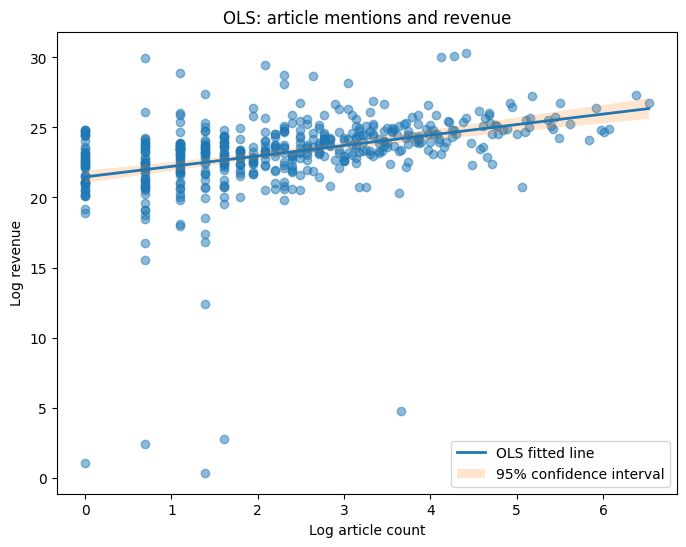

In [66]:
x_line = np.linspace(
    ols_df["log_article_count"].min(),
    ols_df["log_article_count"].max(),
    100
)

pred_df = pd.DataFrame({
    "log_article_count": x_line
})

pred = ols_model.get_prediction(pred_df).summary_frame()

plt.figure(figsize=(8, 6))

plt.scatter(
    ols_df["log_article_count"],
    ols_df["log_revenue"],
    alpha=0.5
)

plt.plot(
    x_line,
    pred["mean"],
    linewidth=2,
    label="OLS fitted line"
)

plt.fill_between(
    x_line,
    pred["mean_ci_lower"],
    pred["mean_ci_upper"],
    alpha=0.2,
    label="95% confidence interval"
)

plt.xlabel("Log article count")
plt.ylabel("Log revenue")
plt.title("OLS: article mentions and revenue")
plt.legend()

plt.show()

In [67]:
ols_df = analysis_mentions_df[["company", "market_cap", "article_count"]].copy()

ols_df = ols_df[
    ols_df["market_cap"].notna()
].copy()

ols_df["log_market_cap"] = np.log(ols_df["market_cap"])
ols_df["log_article_count"] = np.log(ols_df["article_count"])

ols_model = smf.ols(
    "log_market_cap ~ log_article_count",
    data=ols_df
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:         log_market_cap   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     84.12
Date:                Tue, 26 May 2026   Prob (F-statistic):           2.73e-16
Time:                        11:55:43   Log-Likelihood:                -326.99
No. Observations:                 157   AIC:                             658.0
Df Residuals:                     155   BIC:                             664.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            21.6371      0.33

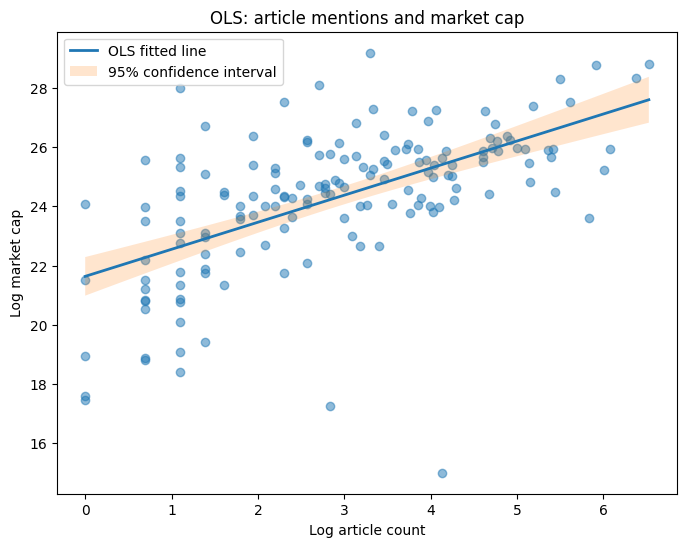

In [68]:
x_line = np.linspace(
    ols_df["log_article_count"].min(),
    ols_df["log_article_count"].max(),
    100
)

pred_df = pd.DataFrame({
    "log_article_count": x_line
})

pred = ols_model.get_prediction(pred_df).summary_frame()

plt.figure(figsize=(8, 6))

plt.scatter(
    ols_df["log_article_count"],
    ols_df["log_market_cap"],
    alpha=0.5
)

plt.plot(
    x_line,
    pred["mean"],
    linewidth=2,
    label="OLS fitted line"
)

plt.fill_between(
    x_line,
    pred["mean_ci_lower"],
    pred["mean_ci_upper"],
    alpha=0.2,
    label="95% confidence interval"
)

plt.xlabel("Log article count")
plt.ylabel("Log market cap")
plt.title("OLS: article mentions and market cap")
plt.legend()

plt.show()